In [ ]:
!pip install git+https://github.com/openai/CLIP.git transformers accelerate



  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-51t0bo5u
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-51t0bo5u
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=954041f18af6d1dd5faf965f43b0b13c5a8645cd30ec9125a749aba8996b8ea7
  Stored in directory: /tmp/pip-ephem-wheel-cache-cn7w4cpo/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
check the weight as well, train afew times if teh bed results ar ebetter and using teh emotions

In [ ]:
!pip install sentence-transformers

In [ ]:
import json
import requests
import numpy as np
import pandas as pd
from PIL import Image
from io import BytesIO
from pathlib import Path
from tqdm import tqdm
import torch

import clip
from transformers import Blip2Processor, Blip2ForConditionalGeneration

from sentence_transformers import SentenceTransformer


In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

ROOT_DIR = "/content/drive/MyDrive/CompNeuroscience-P1"


Mounted at /content/drive


In [ ]:
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE     = 500
OUTPUT_DIR     = Path(ROOT_DIR) / "lamem_features"
IMAGES_DIR     = Path(ROOT_DIR) / "lamem_images"
DATA_JSON      = Path(ROOT_DIR) / "data.json"
EMOTIONS       = ["amusement", "excitement", "awe", "contentment", "sadness"]
BASE_IMAGE_URL = "http://memorability.csail.mit.edu/imgs/"

OUTPUT_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

In [ ]:
DEVICE

'cuda'

In [ ]:
clip_model, clip_preprocess = clip.load("ViT-L/14", device=DEVICE) #B
clip_model.eval()

100%|███████████████████████████████████████| 890M/890M [00:10<00:00, 90.8MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)


In [ ]:
emotion_prompts      = [f"a photo that conveys {e}" for e in EMOTIONS]
emotion_tokens       = clip.tokenize(emotion_prompts).to(DEVICE)
with torch.no_grad():
    emotion_text_features = clip_model.encode_text(emotion_tokens)
    emotion_text_features = emotion_text_features / emotion_text_features.norm(dim=-1, keepdim=True)

In [ ]:
#dino b2

# copilot - no data used for training

# Check if emotion weights are greater than 0

# Train neuron 10x

# statistical significance nas diffs com e sem emotions

In [ ]:
blip_processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
blip_model     = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
).to(DEVICE)
blip_model = torch.compile(blip_model)
blip_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

OptimizedModule(
  (_orig_mod): Blip2ForConditionalGeneration(
    (vision_model): Blip2VisionModel(
      (embeddings): Blip2VisionEmbeddings(
        (patch_embedding): Conv2d(3, 1408, kernel_size=(14, 14), stride=(14, 14))
      )
      (encoder): Blip2Encoder(
        (layers): ModuleList(
          (0-38): 39 x Blip2EncoderLayer(
            (self_attn): Blip2Attention(
              (qkv): Linear(in_features=1408, out_features=4224, bias=True)
              (projection): Linear(in_features=1408, out_features=1408, bias=True)
            )
            (layer_norm1): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
            (mlp): Blip2MLP(
              (activation_fn): GELUActivation()
              (fc1): Linear(in_features=1408, out_features=6144, bias=True)
              (fc2): Linear(in_features=6144, out_features=1408, bias=True)
            )
            (layer_norm2): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
          )
        )
      )
      (post_

In [ ]:
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")  # 384-dim, fast and lightweight

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def fetch_and_save_image(url: str, local_path: Path) -> Image.Image | None:
    # print(url)
    if local_path.exists():
        return Image.open(local_path).convert("RGB")
    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        # print(r.status_code)
        local_path.parent.mkdir(parents=True, exist_ok=True)
        local_path.write_bytes(r.content)
        print(f"Image saved at: {local_path}")
        return Image.open(BytesIO(r.content)).convert("RGB")
    except Exception:
        return None


def get_clip_features(image: Image.Image) -> np.ndarray:
    tensor = clip_preprocess(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        feat = clip_model.encode_image(tensor)
        feat = feat / feat.norm(dim=-1, keepdim=True)
    return feat.cpu().float().numpy()[0]  # (768,)


def get_emotion(clip_feat: np.ndarray) -> tuple[str, float, dict]:
    feat = torch.tensor(clip_feat).unsqueeze(0).to(DEVICE).to(emotion_text_features.dtype)
    sims = (feat @ emotion_text_features.T).softmax(dim=-1).cpu().float().numpy()[0]
    return EMOTIONS[sims.argmax()], float(sims.max()), dict(zip(EMOTIONS, sims.tolist()))


def get_caption(image: Image.Image) -> str:
    inputs = blip_processor(images=image, return_tensors="pt").to(
        DEVICE, torch.float16 if DEVICE == "cuda" else torch.float32
    )
    with torch.no_grad():
        out = blip_model.generate(**inputs, max_new_tokens=60)
    return blip_processor.decode(out[0], skip_special_tokens=True).strip()


def save_batch(records: list[dict], clip_vecs: list[np.ndarray], batch_idx: int):
    df   = pd.DataFrame(records)
    path = OUTPUT_DIR / f"batch_{batch_idx:04d}.parquet"
    df.to_parquet(path, index=False)

    clip_path = OUTPUT_DIR / f"batch_{batch_idx:04d}_clip.npy"
    np.save(clip_path, np.stack(clip_vecs))  # (500, 768)

    print(f"  Saved {len(records)} records → {path.name} + {clip_path.name}")



In [ ]:
with open(DATA_JSON) as f:
    data = json.load(f)

In [ ]:
print(f"Total images in JSON: {len(data)}")

Total images in JSON: 16815


In [ ]:
done_files  = sorted(OUTPUT_DIR.glob("batch_*.parquet"))
done_count  = sum(len(pd.read_parquet(p)) for p in done_files)
batch_num   = len(done_files)
print(f"Already processed: {done_count} images. Resuming from index {done_count}.")


Already processed: 16815 images. Resuming from index 16815.


In [ ]:
meta_buffer = []   # list of dicts  → parquet
clip_buffer = []   # list of (768,) → .npy

for item in tqdm(data[done_count:], initial=done_count, total=len(data)):
    local_path = IMAGES_DIR / item["name"]
    img_url    = BASE_IMAGE_URL + item["name"]

    image = fetch_and_save_image(img_url, local_path)

    if image is None:
        print("ERROR")
        meta_buffer.append({
            "name":             item["name"],
            "local_path":       str(local_path),
            "dataset":          item.get("dataset", ""),
            "memscore":         item.get("memscore", None),
            "original_emotion": item.get("emotion", ""),
            "error":            True,
        })
        clip_buffer.append(np.zeros(768, dtype=np.float32))  # placeholder to keep index aligned
    else:
        clip_feat                                   = get_clip_features(image)
        emotion_label, emotion_conf, emotion_scores = get_emotion(clip_feat)
        caption                                     = get_caption(image)

        meta_buffer.append({
            "name":              item["name"],
            "local_path":        str(local_path),
            "dataset":           item.get("dataset", ""),
            "memscore":          item.get("memscore", None),
            "original_emotion":  item.get("emotion", ""),
            "clip_emotion":      emotion_label,
            "clip_emotion_conf": emotion_conf,
            "caption":           caption,
            "error":             False,
            **{f"emotion_{e}": emotion_scores[e] for e in EMOTIONS},
        })
        clip_buffer.append(clip_feat)

    if len(meta_buffer) >= BATCH_SIZE:
        save_batch(meta_buffer, clip_buffer, batch_num)
        batch_num  += 1
        meta_buffer = []
        clip_buffer = []

if meta_buffer:
    save_batch(meta_buffer, clip_buffer, batch_num)


100%|██████████| 16815/16815 [00:00<?, ?it/s]


In [ ]:
print("Concatenating metadata...")
all_dfs = [pd.read_parquet(p) for p in sorted(OUTPUT_DIR.glob("batch_*.parquet"))]
final_df = pd.concat(all_dfs, ignore_index=True)
final_df.to_parquet(OUTPUT_DIR / "lamem_features_full.parquet", index=False)
print(f"Parquet saved - shape: {final_df.shape}")

Concatenating metadata...
Parquet saved - shape: (16815, 14)


In [ ]:
print("Concatenating CLIP embeddings...")
clip_arrays = [np.load(p) for p in sorted(OUTPUT_DIR.glob("batch_*_clip.npy"))]
clip_matrix = np.concatenate(clip_arrays, axis=0)  # (N, 768)
np.save(OUTPUT_DIR / "clip_embeddings.npy", clip_matrix)
print(f"CLIP embeddings saved — shape: {clip_matrix.shape}")

Concatenating CLIP embeddings...
CLIP embeddings saved — shape: (16815, 768)


In [ ]:
print("Generating SBERT caption embeddings...")
captions = final_df["caption"].fillna("").tolist()
caption_matrix = sbert_model.encode(captions, batch_size=256, show_progress_bar=True)  # (N, 384)
np.save(OUTPUT_DIR / "caption_embeddings.npy", caption_matrix.astype(np.float32))
print(f"SBERT embeddings saved — shape: {caption_matrix.shape}")


Generating SBERT caption embeddings...


Batches:   0%|          | 0/66 [00:00<?, ?it/s]

SBERT embeddings saved — shape: (16815, 384)


In [ ]:
print(f"lamem_features_full.parquet - {final_df.shape}")
print(f"clip_embeddings.npy - {clip_matrix.shape}")
print(f"caption_embeddings.npy  - {caption_matrix.shape}")
print(f"Images saved locally  - {len(list(IMAGES_DIR.rglob('*.jpg')))}")
print(f"Original emotion labels - {(final_df['original_emotion'] != '').sum()}")
print(f"Errors - {final_df['error'].sum()}")

lamem_features_full.parquet - (16815, 14)
clip_embeddings.npy - (16815, 768)
caption_embeddings.npy  - (16815, 384)
Images saved locally  - 16815
Original emotion labels - 540
Errors - 0


In [ ]:
from google.colab import runtime
runtime.unassign()

In [ ]:
# ---------------------------------------------

In [ ]:
import pandas as pd

df = pd.read_parquet(f"{ROOT_DIR}/lamem_features/batch_0000.parquet")

print(df.head())

              name                                         local_path  \
0   original/2.jpg  /content/drive/MyDrive/CompNeuroscience-P1/lam...   
1   original/4.jpg  /content/drive/MyDrive/CompNeuroscience-P1/lam...   
2  original/30.jpg  /content/drive/MyDrive/CompNeuroscience-P1/lam...   
3  original/53.jpg  /content/drive/MyDrive/CompNeuroscience-P1/lam...   
4  original/59.jpg  /content/drive/MyDrive/CompNeuroscience-P1/lam...   

    dataset  memscore original_emotion clip_emotion  clip_emotion_conf  \
0  abnormal  0.694118                           awe           0.200562   
1       art  0.792208        amusement    amusement           0.203247   
2  abnormal  0.848101                    excitement           0.200806   
3       art  0.764706       excitement   excitement           0.203613   
4       art  0.758242              awe      sadness           0.203247   

                                             caption  error  \
0  a gondola with people on it and a piano on the... 

In [ ]:

df.original_emotion.unique()

array(['', 'amusement', 'excitement', 'awe', 'contentment', 'sad'],
      dtype=object)

In [ ]:
df.emo

In [ ]:
sample = df[["name", "memscore", "clip_emotion", "caption"]].rename(columns={"name": "Path", "memscore": "Memory Score", "clip_emotion": "Dominant Emotion", "caption": "Caption"}).head(5)

sample

,Path,Memory Score,Dominant Emotion,Caption
0,original/2.jpg,0.694118,awe,a gondola with people on it and a piano on the...
1,original/4.jpg,0.792208,amusement,two men in a cart with pink balloons
2,original/30.jpg,0.848101,excitement,a red car flying in the air with a large wing
3,original/53.jpg,0.764706,excitement,a man standing on top of a mountain with his a...
4,original/59.jpg,0.758242,sadness,a person holding a small white flower in their...


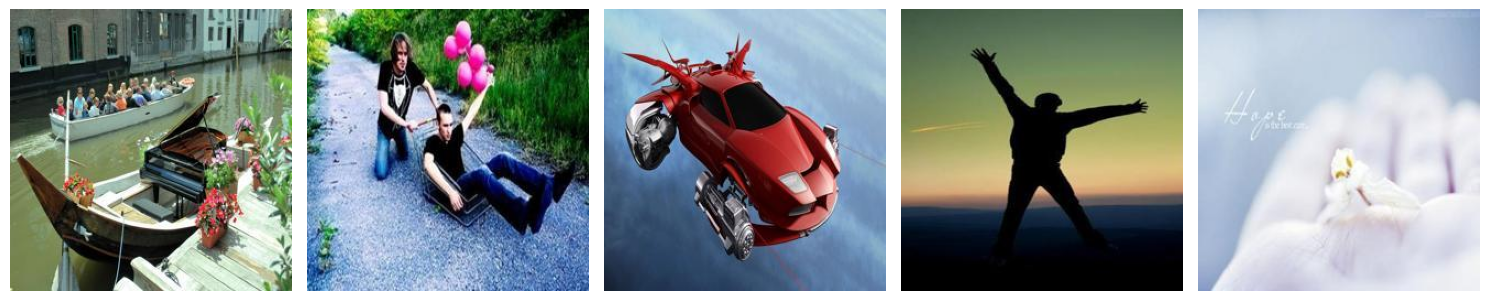

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Supondo que seu DataFrame se chama df e a coluna é 'Path'
paths = sample['Path'].tolist()

fig, axes = plt.subplots(1, len(paths), figsize=(15, 5))

for i, path in enumerate(paths):
    path = f"{ROOT_DIR}/lamem_images/{path}"
    img = mpimg.imread(path)
    axes[i].imshow(img)
    axes[i].axis('off')  # tira eixo

plt.tight_layout()
plt.show()

In [ ]:
sample.T

,62,0,255,203,221
Path,original/1205.jpg,original/2.jpg,original/5735.jpg,original/4114.jpg,original/4603.jpg
Memory Score,0.827586,0.694118,0.765432,0.9375,0.682927
Dominant Emotion,contentment,awe,sadness,amusement,awe
Caption,a motorcycle is shown in a 3d rendering,a gondola with people on it and a piano on the...,a futuristic motorcycle is shown on a white ba...,an elephant is standing in the middle of a liv...,a painting with a lot of colors and paint


In [ ]:
from IPython.display import display

display(sample.T.style.set_properties(**{
    'white-space': 'pre-wrap'
}))

,0,1,2,3,4
Path,original/2.jpg,original/4.jpg,original/30.jpg,original/53.jpg,original/59.jpg
Memory Score,0.694118,0.792208,0.848101,0.764706,0.758242
Dominant Emotion,awe,amusement,excitement,excitement,sadness
Caption,a gondola with people on it and a piano on the side,two men in a cart with pink balloons,a red car flying in the air with a large wing,a man standing on top of a mountain with his arms outstretched,a person holding a small white flower in their hand
